In [1]:
import xarray as xr
import numpy as np
import yaml
from pathlib import Path

from xseas import SeasonDetect, tile_labels
from xseas.models.perceptron import load_models, evaluate_custom

In [2]:
data = xr.open_dataset('/Users/jacopograssi/Documents/XSeas/working_folder/data/ERA5/prenormalized/ERA5_prenorm_w15.nc')
data = data.sel(time=slice('2010-01-01', '2018-12-31'))
data

Cannot create earthkit-data config directory=/Users/jacopograssi/.config/earthkit/data
Traceback (most recent call last):
  File "/opt/anaconda3/envs/Xseas/lib/python3.11/site-packages/earthkit/data/core/config.py", line 672, in _init_config_file
    os.makedirs(config_dir, 0o700)
  File "<frozen os>", line 215, in makedirs
  File "<frozen os>", line 225, in makedirs
PermissionError: [Errno 13] Permission denied: '/Users/jacopograssi/.config/earthkit'
Cannot load earthkit-data config (/Users/jacopograssi/.config/earthkit/data/config.yaml), reverting to defaults
Traceback (most recent call last):
  File "/opt/anaconda3/envs/Xseas/lib/python3.11/site-packages/earthkit/data/core/config.py", line 698, in _init_config
    with open(config_yaml) as f:
         ^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/Users/jacopograssi/.config/earthkit/data/config.yaml'


<xarray.Dataset> Size: 68MB
Dimensions:      (time: 3285, lon: 36, lat: 36)
Coordinates:
  * time         (time) object 26kB 2010-01-01 09:00:00 ... 2018-12-31 09:00:00
  * lon          (lon) float64 288B 65.0 66.0 67.0 68.0 ... 97.0 98.0 99.0 100.0
  * lat          (lat) float64 288B 5.0 6.0 7.0 8.0 9.0 ... 37.0 38.0 39.0 40.0
    spatial_ref  int64 8B ...
Data variables:
    2t           (time, lat, lon) float32 17MB ...
    tp           (time, lat, lon) float32 17MB ...
    u            (time, lat, lon) float32 17MB ...
    v            (time, lat, lon) float32 17MB ...
Attributes:
    long_name:     2 metre temperature
    units:         K
    code:          167
    table:         128
    cell_methods:  time: mean
    institution:   ECMWF

In [3]:
with open('paths.local.yaml', 'r') as file:
    paths = yaml.safe_load(file)

WORKING_FOLDER = Path(paths['WORKING_FOLDER'])
CONFIG_FILE = 'four_seas_all_vars.yaml'

s = SeasonDetect(WORKING_FOLDER, CONFIG_FILE)

✅ Using existing XSeas project at: /Users/jacopograssi/Documents/XSeas/working_folder
⚠️  Recommended key missing: parameters_projections


In [4]:
# The saved clustering (ground-truth season labels) is empty/corrupted, regenerate it
#s.perform_clustering()

In [5]:
# Attach seasonal labels (clustering breakpoints) to the ERA5 test period
# clustering_ds = xr.open_dataset(s.clustering_path)
# data_labeled = tile_labels(data, clustering_ds, s.n_seasons)

# # Build the (lat, lon, time, features+1) array with the same variable ordering used at training time
# feature_vars = [v for v in data_labeled.data_vars if v != 'labels']
# feature_vars_sorted = sorted(feature_vars)
# data_ordered = data_labeled[feature_vars_sorted + ['labels']]

# arr = data_ordered.to_array().values      # (features+1, time, lat, lon)
# arr = arr.transpose(2, 3, 1, 0)           # (lat, lon, time, features+1)

# n_features = arr.shape[-1] - 1
# n_features

In [6]:
# Load the perceptron classifier trained on ERA5 (one model per grid point)
# models = load_models(s.perceptron_path)
# models.shape

In [7]:
# # Evaluate the model on ERA5 and derive the per-class F1 score
# accuracy, precision, recall = evaluate_custom(arr, models, n_features)
# f1 = 2 * (precision * recall) / (precision + recall)

# f1_da = xr.DataArray(
#     f1,
#     dims=('lat', 'lon', 'cluster'),
#     coords={'lat': data['lat'], 'lon': data['lon'], 'cluster': np.arange(f1.shape[-1])},
#     name='f1_score'
# )

# for c in range(s.n_seasons):
#     print(f'Average F1 score for cluster {c}:', np.nanmean(f1_da.sel(cluster=c).values))

In [8]:
# Save the ERA5 evaluation (accuracy, precision, recall, f1) alongside the CMIP6 evaluations
# eval_ds = xr.Dataset(
#     {
#         'accuracy': (('lat', 'lon', 'cluster'), accuracy),
#         'precision': (('lat', 'lon', 'cluster'), precision),
#         'recall': (('lat', 'lon', 'cluster'), recall),
#         'f1': (('lat', 'lon', 'cluster'), f1),
#     },
#     coords={'lat': data['lat'], 'lon': data['lon'], 'cluster': np.arange(f1.shape[-1])}
# )

# eval_dir = s.perceptron_path / 'evaluation'
# eval_dir.mkdir(parents=True, exist_ok=True)
# eval_ds.to_netcdf(eval_dir / f'eval_{s.name}_ERA5.nc')

eval_ds = xr.open_dataset(s.perceptron_path / 'evaluation' / f'eval_{s.name}_ERA5.nc')

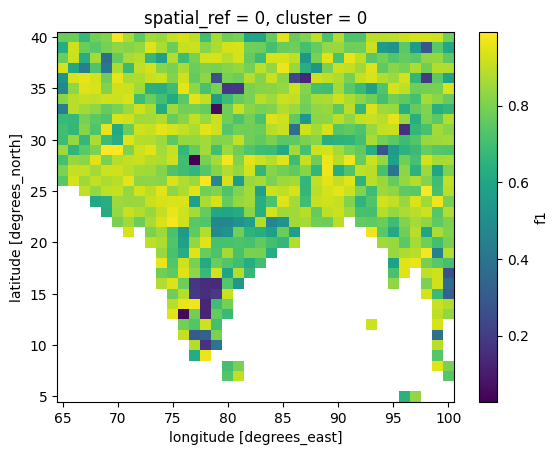

In [9]:
eval_ds.f1.isel(cluster=0).plot()